In [4]:
import numpy as np
import xarray as xr
from scipy.signal import detrend
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sst_pix2pix_annual_cycle import (
    SSTDataset, Generator, compute_climatology, 
    rollout_prediction, get_seasonal_encoding
)
from train_sst_model import (
    Discriminator, CombinedLoss, 
    plot_training_history, plot_predictions
)

In [5]:
# # ============================================================================
# # COBE Data Processing
# # ============================================================================

# def load_and_process_cobe_data(dataset_path, mask_path='../../Data/mask.npy', 
#                                  n_train=1428, n_val=100, ensemble_id=0):
#     """
#     Load and process COBE SST data.
    
#     Args:
#         dataset_path: Path to COBE netCDF file
#         mask_path: Path to mask file
#         n_train: Number of training samples
#         n_val: Number of validation samples
#         ensemble_id: Which ensemble member to use (if multiple)
    
#     Returns:
#         train_data, val_data, test_data, train_months, val_months, test_months, mask
#     """
#     print(f"Loading dataset from: {dataset_path}")
    
#     # Load dataset
#     ds = xr.open_dataset(dataset_path)
    
#     # Select SST variable
#     sst = ds["sst"]
    
#     climatology = sst.groupby("time.month").mean(dim="time")
#     sst = sst.groupby("time.month")-climatology
#     sst = sst.fillna(0)

#     data = sst.values  # Shape: (time, lat, lon)
    
#     print(f"Data shape: {data.shape}")
#     print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")
    
#     # Load mask
#     mask = np.load(mask_path)
#     print(f"Mask shape: {mask.shape}")
    
#     # Split data
#     train_data = data[:n_train, :, :]
#     val_data = data[n_train:n_train + n_val, :, :]
#     test_data = data[n_train:, :, :]
    
#     print(f"Train shape: {train_data.shape}")
#     print(f"Val shape: {val_data.shape}")
#     print(f"Test shape: {test_data.shape}")
    
#     # Create month arrays (0-11 for each sample)
#     # Assuming data starts from a known month, or extract from dataset
#     # If your dataset has months encoded, extract them. Otherwise:
#     total_samples = data.shape[0]
    
#     # Try to get starting month from dataset metadata
#     if 'mon' in ds.coords:
#         # If months are in coordinates, use them
#         months_all = np.array([(i % 12) for i in range(total_samples)])
#     else:
#         # Default: assume data starts in January (month 0)
#         months_all = np.array([i % 12 for i in range(total_samples)])
    
#     train_months = months_all[:n_train]
#     val_months = months_all[n_train:n_train + n_val]
#     test_months = months_all[n_train:]
    
#     return train_data, val_data, test_data, train_months, val_months, test_months, mask


In [ ]:
#train_data, val_data, test_data, train_months, val_months, test_months, mask = load_and_process_cobe_data('../../Data/COBE_SST_resize.nc')

NameError: name 'load_and_process_cobe_data' is not defined

In [8]:
# ============================================================================
# CMIP6 Data Processing
# ============================================================================

def load_and_process_cmip6_data(dataset_path, mask_path='../../Data/mask.npy', 
                                 n_train=1428, n_val=100, ensemble_id=0):
    """
    Load and process CMIP6 SST data.
    
    Args:
        dataset_path: Path to CMIP6 netCDF file
        mask_path: Path to mask file
        n_train: Number of training samples
        n_val: Number of validation samples
        ensemble_id: Which ensemble member to use (if multiple)
    
    Returns:
        train_data, val_data, test_data, train_months, val_months, test_months, mask
    """
    print(f"Loading dataset from: {dataset_path}")
    
    # Load dataset
    ds = xr.open_dataset(dataset_path)
    
    # Select SST variable
    sst = ds["sst"]
    
    # If multiple ensembles, select one
    if "ensemble" in sst.dims:
        print(f"Multiple ensembles found. Selecting ensemble {ensemble_id}")
        sst = sst.isel(ensemble=ensemble_id)
    
    # Fill NaN values with 0
    sst = sst.fillna(0)
    
    sst = sst - sst.mean(dim="years")  # Center data by removing mean over time

    # Stack years and months into time dimension
    sst_time = (
        sst
        .stack(time=("years", "mon"))
        .transpose("time", "lat", "lon")
    ).fillna(0)
    
    data = sst_time.values  # Shape: (time, lat, lon)
    
    print(f"Data shape: {data.shape}")
    print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")
    
    # Load mask
    mask = np.load(mask_path)
    print(f"Mask shape: {mask.shape}")
    
    # Split data
    train_data = data[:n_train, :, :]
    val_data = data[n_train:n_train + n_val, :, :]
    test_data = data[n_train:, :, :]
    
    print(f"Train shape: {train_data.shape}")
    print(f"Val shape: {val_data.shape}")
    print(f"Test shape: {test_data.shape}")
    
    # Create month arrays (0-11 for each sample)
    # Assuming data starts from a known month, or extract from dataset
    # If your dataset has months encoded, extract them. Otherwise:
    total_samples = data.shape[0]
    
    # Try to get starting month from dataset metadata
    if 'mon' in ds.coords:
        # If months are in coordinates, use them
        months_all = np.array([(i % 12) for i in range(total_samples)])
    else:
        # Default: assume data starts in January (month 0)
        months_all = np.array([i % 12 for i in range(total_samples)])
    
    train_months = months_all[:n_train]
    val_months = months_all[n_train:n_train + n_val]
    test_months = months_all[n_train:]
    
    return train_data, val_data, test_data, train_months, val_months, test_months, mask


def process_with_detrending(data, detrend_type='linear'):
    """
    Optional: Apply detrending to SST data.
    
    Args:
        data: SST data (time, lat, lon)
        detrend_type: 'linear' or 'constant'
    
    Returns:
        detrended data
    """
    if detrend_type is None:
        return data
    
    print(f"Applying {detrend_type} detrending...")
    data_detrended = np.zeros_like(data)
    
    # Detrend along time axis for each spatial point
    for i in range(data.shape[1]):
        for j in range(data.shape[2]):
            data_detrended[:, i, j] = detrend(data[:, i, j], type=detrend_type)
    
    return data_detrended


def normalize_data(train_data, val_data, test_data, method='standardize'):
    """
    Normalize SST data.
    
    Args:
        train_data, val_data, test_data: SST arrays
        method: 'standardize' (z-score) or 'minmax' (0-1 scaling)
    
    Returns:
        normalized data and normalization parameters
    """
    if method == 'standardize':
        mean = np.mean(train_data)
        std = np.std(train_data)
        
        train_norm = (train_data - mean) / std
        val_norm = (val_data - mean) / std
        test_norm = (test_data - mean) / std
        
        norm_params = {'mean': mean, 'std': std, 'method': 'standardize'}
        
        print(f"Standardization - Mean: {mean:.4f}, Std: {std:.4f}")
        
    elif method == 'minmax':
        min_val = np.min(train_data)
        max_val = np.max(train_data)
        
        train_norm = (train_data - min_val) / (max_val - min_val)
        val_norm = (val_data - min_val) / (max_val - min_val)
        test_norm = (test_data - min_val) / (max_val - min_val)
        
        norm_params = {'min': min_val, 'max': max_val, 'method': 'minmax'}
        
        print(f"Min-Max scaling - Min: {min_val:.4f}, Max: {max_val:.4f}")
    
    else:
        # No normalization
        train_norm, val_norm, test_norm = train_data, val_data, test_data
        norm_params = {'method': 'none'}
    
    return train_norm, val_norm, test_norm, norm_params


def denormalize_data(data, norm_params):
    """
    Denormalize data back to original scale.
    
    Args:
        data: normalized data
        norm_params: dictionary with normalization parameters
    
    Returns:
        denormalized data
    """
    if norm_params['method'] == 'standardize':
        return data * norm_params['std'] + norm_params['mean']
    elif norm_params['method'] == 'minmax':
        return data * (norm_params['max'] - norm_params['min']) + norm_params['min']
    else:
        return data


In [9]:
# ============================================================================
# Load Trained Model
# ============================================================================

def load_trained_model(checkpoint_path, device='cpu'):
    """
    Load trained generator from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        device: 'cuda' or 'cpu'
    
    Returns:
        generator, climatology, norm_params, num_input_months
    """
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    num_input_months = checkpoint['num_input_months']
    in_channels = num_input_months + 2
    
    generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    climatology = checkpoint['climatology']
    norm_params = checkpoint['norm_params']
    
    print(f"Model loaded from epoch {checkpoint['epoch']}")
    if 'best_val_loss' in checkpoint:
        print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
    
    return generator, climatology, norm_params, num_input_months



In [ ]:
# ============================================================================
# Training with CMIP6 Data
# ============================================================================

def train_cmip6_model(dataset_path, mask_path='../Data/mask.npy',
                      n_train=1428, n_val=100, ensemble_id=0,
                      num_epochs=100, num_input_months=3, 
                      batch_size=16, lr=0.0002, lambda_clim=0.1,
                      normalize=True, apply_detrend=None,
                      checkpoint_dir='./checkpoints',load_weight_path=None):
    """
    Complete training pipeline for CMIP6 SST data.
    
    Args:
        dataset_path: Path to CMIP6 netCDF file
        mask_path: Path to mask file
        n_train: Number of training samples
        n_val: Number of validation samples
        ensemble_id: Which ensemble to use
        num_epochs: Training epochs
        num_input_months: Number of previous months as input
        batch_size: Batch size
        lr: Learning rate
        lambda_clim: Climatology loss weight
        normalize: Whether to normalize data
        apply_detrend: 'linear', 'constant', or None
        checkpoint_dir: Directory to save checkpoints
    """
    import os
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")
    
    # ===========================
    # 1. Load and Process Data
    # ===========================
    train_data, val_data, test_data, train_months, val_months, test_months, mask = \
        load_and_process_cmip6_data(dataset_path, mask_path, n_train, n_val, ensemble_id)
    
    # Optional detrending
    if apply_detrend:
        train_data = process_with_detrending(train_data, apply_detrend)
        val_data = process_with_detrending(val_data, apply_detrend)
        test_data = process_with_detrending(test_data, apply_detrend)
    
    # Normalize data
    if normalize:
        train_data, val_data, test_data, norm_params = normalize_data(
            train_data, val_data, test_data, method='standardize'
        )
    else:
        norm_params = {'method': 'none'}
    
    # ===========================
    # 2. Compute Climatology
    # ===========================
    print("\nComputing climatology from training data...")
    climatology = compute_climatology(train_data, train_months)
    print(f"Climatology shape: {climatology.shape}")
    
    # ===========================
    # 3. Create Datasets
    # ===========================
    print("\nCreating datasets...")
    train_dataset = SSTDataset(
        sst_data=train_data,
        months=train_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    val_dataset = SSTDataset(
        sst_data=val_data,
        months=val_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=4,
        pin_memory=True if device == 'cuda' else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True if device == 'cuda' else False
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # ===========================
    # 4. Initialize Models
    # ===========================
    in_channels = num_input_months + 2  # SST channels + seasonal encoding
    print(f"\nInitializing models with {in_channels} input channels...")
    
    #generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    #discriminator = Discriminator(in_channels=in_channels + 1).to(device)
    
    # Initialize weights
    # def init_weights(m):
    #     if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
    #         torch.nn.init.normal_(m.weight, 0.0, 0.02)
    #         if m.bias is not None:
    #             torch.nn.init.constant_(m.bias, 0)
    #     elif isinstance(m, torch.nn.BatchNorm2d):
    #         torch.nn.init.normal_(m.weight, 1.0, 0.02)
    #         torch.nn.init.constant_(m.bias, 0)
    
    # generator.apply(init_weights)
    # discriminator.apply(init_weights)
    device = 'cuda' #if torch.cuda.is_available() else 'cpu'

    # Load model
    generator, climatology, norm_params, num_input_months = load_trained_model(
        load_weight_path, device
    )
    
    # ===========================
    # 5. Setup Training
    # ===========================
    criterion = torch.nn.L1Loss()
    
    #bce_loss = torch.nn.BCEWithLogitsLoss()
    
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    #d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    
    g_scheduler = torch.optim.lr_scheduler.StepLR(g_optimizer, step_size=30, gamma=0.5)
    #d_scheduler = torch.optim.lr_scheduler.StepLR(d_optimizer, step_size=30, gamma=0.5)
    
    # Training history
    history = {
        'train_g_loss': [],
        #'train_d_loss': [],
        'train_l1_loss': [],
        #'train_clim_loss': [],
        'val_g_loss': [],
        'val_l1_loss': []
    }
    
    # ===========================
    # 6. Training Loop
    # ===========================
    print(f"\nStarting training for {num_epochs} epochs...")
    print("=" * 70)
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Train
        generator.train()
        #discriminator.train()
        
        epoch_g_loss = 0
        #epoch_d_loss = 0
        #epoch_l1_loss = 0
        #epoch_clim_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            inputs = batch['input'].to(device)
            targets = batch['target'].to(device)
            # target_months = batch['target_month'].to(device)
            
            # Train Discriminator
            #d_optimizer.zero_grad()
            
            # real_pair = torch.cat([inputs, targets], dim=1)
            # d_real = discriminator(real_pair)
            # real_labels = torch.ones_like(d_real) * 0.9
            # d_real_loss = bce_loss(d_real, real_labels)
            
            fake_outputs = generator(inputs)
            # fake_pair = torch.cat([inputs, fake_outputs.detach()], dim=1)
            # d_fake = discriminator(fake_pair)
            # fake_labels = torch.zeros_like(d_fake) + 0.1
            # d_fake_loss = bce_loss(d_fake, fake_labels)
            
            # d_loss = (d_real_loss + d_fake_loss) / 2
            # d_loss.backward()
            # d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            
            # fake_outputs = generator(inputs)
            # fake_pair = torch.cat([inputs, fake_outputs], dim=1)
            # d_fake = discriminator(fake_pair)
            
            # real_labels = torch.ones_like(d_fake)
            # g_adv_loss = bce_loss(d_fake, real_labels)
            #print(f"Fake outputs : {fake_outputs}, Target : {targets}")
            g_recon_loss = criterion(fake_outputs, targets)
            
            g_loss = g_recon_loss
            g_loss.backward()
            g_optimizer.step()
            
            epoch_g_loss += g_loss.item()
            # epoch_d_loss += d_loss.item()
            #epoch_l1_loss += loss_dict['l1']
            #epoch_clim_loss += loss_dict['climatology']
            
            if batch_idx % 50 == 0:
                print(f'Epoch {epoch+1}/{num_epochs} [{batch_idx}/{len(train_loader)}]')
        
        # Validation
        generator.eval()
        val_g_loss = 0
        # val_l1_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['input'].to(device)
                targets = batch['target'].to(device)
                #target_months = batch['target_month'].to(device)
                
                fake_outputs = generator(inputs)
                g_recon_loss = criterion(fake_outputs, targets)
                
                val_g_loss += g_recon_loss.item()
                #val_l1_loss += loss_dict['l1']
        
        # Update schedulers
        g_scheduler.step()
        # d_scheduler.step()
        
        # Record history
        history['train_g_loss'].append(epoch_g_loss / len(train_loader))
        #history['train_d_loss'].append(epoch_d_loss / len(train_loader))
        #history['train_l1_loss'].append(epoch_l1_loss / len(train_loader))
        #history['train_clim_loss'].append(epoch_clim_loss / len(train_loader))
        history['val_g_loss'].append(val_g_loss / len(val_loader))
        #history['val_l1_loss'].append(val_l1_loss / len(val_loader))
        
        avg_val_loss = val_g_loss / len(val_loader)
        
        print(f'\n{"="*70}')
        print(f'Epoch {epoch+1}/{num_epochs} Summary:')
        print(f'Train - G: {history["train_g_loss"][-1]:.4f} ')
        print(f'Val   - G: {avg_val_loss:.4f}')
        print(f'{"="*70}\n')
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                # 'discriminator_state_dict': discriminator.state_dict(),
                'g_optimizer_state_dict': g_optimizer.state_dict(),
                #'d_optimizer_state_dict': d_optimizer.state_dict(),
                'history': history,
                # 'climatology': climatology,
                'norm_params': norm_params,
                'num_input_months': num_input_months,
                'best_val_loss': best_val_loss
            }, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"✓ Best model saved (val_loss: {best_val_loss:.4f})")
        
        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                #'discriminator_state_dict': discriminator.state_dict(),
                'g_optimizer_state_dict': g_optimizer.state_dict(),
                #'d_optimizer_state_dict': d_optimizer.state_dict(),
                'history': history,
                #'climatology': climatology,
                'norm_params': norm_params,
                'num_input_months': num_input_months
            }, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth'))
    
    # Plot training history
    plot_training_history_with_val(history, save_path='training_history.png')
    
    return generator, history, climatology, norm_params, test_data, test_months


In [11]:
# ============================================================================
# Fullstack Training with CMIP6 Data
# ============================================================================

def train_cmip6_model_fullstack(dataset_path, mask_path='../Data/mask.npy',
                                n_train=1428, n_val=100, num_ensembles=2,
                                num_epochs=100, num_input_months=3, 
                                batch_size=16, lr=0.0002, lambda_clim=0.1,
                                normalize=True, apply_detrend=None,
                                checkpoint_dir='./checkpoints',load_weight_path=None):
    """
    Complete training pipeline for CMIP6 SST data.
    
    Args:
        dataset_path: Path to CMIP6 netCDF file
        mask_path: Path to mask file
        n_train: Number of training samples
        n_val: Number of validation samples
        ensemble_id: Which ensemble to use
        num_epochs: Training epochs
        num_input_months: Number of previous months as input
        batch_size: Batch size
        lr: Learning rate
        lambda_clim: Climatology loss weight
        normalize: Whether to normalize data
        apply_detrend: 'linear', 'constant', or None
        checkpoint_dir: Directory to save checkpoints
    """
    import os
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}\n")
    
    # ===========================
    # 1. Load and Process Fullstack Data
    # ===========================
    
    train_data, val_data, test_data, train_months, val_months, test_months, mask = \
        load_and_process_cmip6_data(dataset_path, mask_path, n_train, n_val, 0)
    for i in range(1, num_ensembles):
        train_data_i, val_data_i, test_data_i, train_months_i, val_months_i, test_months_i, mask_i  = load_and_process_cmip6_data(dataset_path, mask_path, n_train, n_val, i)
        train_data = np.append(train_data, train_data_i, axis=0)
        val_data = np.append(val_data, val_data_i, axis=0)
        test_data = np.append(test_data, test_data_i, axis=0)
        train_months = np.append(train_months, train_months_i)
        val_months = np.append(val_months, val_months_i)
        test_months = np.append(test_months, test_months_i)
    
    # Optional detrending
    if apply_detrend:
        train_data = process_with_detrending(train_data, apply_detrend)
        val_data = process_with_detrending(val_data, apply_detrend)
        test_data = process_with_detrending(test_data, apply_detrend)
    
    # Normalize data
    if normalize:
        train_data, val_data, test_data, norm_params = normalize_data(
            train_data, val_data, test_data, method='standardize'
        )
    else:
        norm_params = {'method': 'none'}
    
    # ===========================
    # 2. Compute Climatology
    # ===========================
    print("\nComputing climatology from training data...")
    climatology = compute_climatology(train_data, train_months)
    print(f"Climatology shape: {climatology.shape}")
    
    # ===========================
    # 3. Create Datasets
    # ===========================
    print("\nCreating datasets...")
    train_dataset = SSTDataset(
        sst_data=train_data,
        months=train_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    val_dataset = SSTDataset(
        sst_data=val_data,
        months=val_months,
        num_input_months=num_input_months,
        climatology=climatology
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=4,
        pin_memory=True if device == 'cuda' else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True if device == 'cuda' else False
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # ===========================
    # 4. Initialize Models
    # ===========================
    in_channels = num_input_months + 2  # SST channels + seasonal encoding
    print(f"\nInitializing models with {in_channels} input channels...")
    
    #generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    #discriminator = Discriminator(in_channels=in_channels + 1).to(device)
    
    # Initialize weights
    # def init_weights(m):
    #     if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.ConvTranspose2d):
    #         torch.nn.init.normal_(m.weight, 0.0, 0.02)
    #         if m.bias is not None:
    #             torch.nn.init.constant_(m.bias, 0)
    #     elif isinstance(m, torch.nn.BatchNorm2d):
    #         torch.nn.init.normal_(m.weight, 1.0, 0.02)
    #         torch.nn.init.constant_(m.bias, 0)
    
    # generator.apply(init_weights)
    # discriminator.apply(init_weights)
    device = 'cuda' #if torch.cuda.is_available() else 'cpu'

    # Load model
    generator, climatology, norm_params, num_input_months = load_trained_model(
        load_weight_path, device
    )
    
    # ===========================
    # 5. Setup Training
    # ===========================
    criterion = torch.nn.L1Loss()
    #bce_loss = torch.nn.BCEWithLogitsLoss()
    
    g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    #d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    
    g_scheduler = torch.optim.lr_scheduler.StepLR(g_optimizer, step_size=30, gamma=0.5)
    #d_scheduler = torch.optim.lr_scheduler.StepLR(d_optimizer, step_size=30, gamma=0.5)
    
    # Training history
    history = {
        'train_g_loss': [],
        #'train_d_loss': [],
        'train_l1_loss': [],
        #'train_clim_loss': [],
        'val_g_loss': [],
        'val_l1_loss': []
    }
    
    # ===========================
    # 6. Training Loop
    # ===========================
    print(f"\nStarting training for {num_epochs} epochs...")
    print("=" * 70)
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Train
        generator.train()
        #discriminator.train()
        
        epoch_g_loss = 0
        #epoch_d_loss = 0
        #epoch_l1_loss = 0
        #epoch_clim_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            inputs = batch['input'].to(device)
            targets = batch['target'].to(device)
            # target_months = batch['target_month'].to(device)
            
            # Train Discriminator
            #d_optimizer.zero_grad()
            
            # real_pair = torch.cat([inputs, targets], dim=1)
            # d_real = discriminator(real_pair)
            # real_labels = torch.ones_like(d_real) * 0.9
            # d_real_loss = bce_loss(d_real, real_labels)
            
            fake_outputs = generator(inputs)
            # fake_pair = torch.cat([inputs, fake_outputs.detach()], dim=1)
            # d_fake = discriminator(fake_pair)
            # fake_labels = torch.zeros_like(d_fake) + 0.1
            # d_fake_loss = bce_loss(d_fake, fake_labels)
            
            # d_loss = (d_real_loss + d_fake_loss) / 2
            # d_loss.backward()
            # d_optimizer.step()
            
            # Train Generator
            g_optimizer.zero_grad()
            
            # fake_outputs = generator(inputs)
            # fake_pair = torch.cat([inputs, fake_outputs], dim=1)
            # d_fake = discriminator(fake_pair)
            
            # real_labels = torch.ones_like(d_fake)
            # g_adv_loss = bce_loss(d_fake, real_labels)
            #print(f"Fake outputs : {fake_outputs}, Target : {targets}")
            g_recon_loss = criterion(fake_outputs, targets)
            
            g_loss = g_recon_loss
            g_loss.backward()
            g_optimizer.step()
            
            epoch_g_loss += g_loss.item()
            # epoch_d_loss += d_loss.item()
            #epoch_l1_loss += loss_dict['l1']
            #epoch_clim_loss += loss_dict['climatology']
            
            if batch_idx % 50 == 0:
                print(f'Epoch {epoch+1}/{num_epochs} [{batch_idx}/{len(train_loader)}]')
        
        # Validation
        generator.eval()
        val_g_loss = 0
        # val_l1_loss = 0
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['input'].to(device)
                targets = batch['target'].to(device)
                #target_months = batch['target_month'].to(device)
                
                fake_outputs = generator(inputs)
                g_recon_loss = criterion(fake_outputs, targets)
                
                val_g_loss += g_recon_loss.item()
                #val_l1_loss += loss_dict['l1']
        
        # Update schedulers
        g_scheduler.step()
        # d_scheduler.step()
        
        # Record history
        history['train_g_loss'].append(epoch_g_loss / len(train_loader))
        #history['train_d_loss'].append(epoch_d_loss / len(train_loader))
        #history['train_l1_loss'].append(epoch_l1_loss / len(train_loader))
        #history['train_clim_loss'].append(epoch_clim_loss / len(train_loader))
        history['val_g_loss'].append(val_g_loss / len(val_loader))
        #history['val_l1_loss'].append(val_l1_loss / len(val_loader))
        
        avg_val_loss = val_g_loss / len(val_loader)
        
        print(f'\n{"="*70}')
        print(f'Epoch {epoch+1}/{num_epochs} Summary:')
        print(f'Train - G: {history["train_g_loss"][-1]:.4f} ')
        print(f'Val   - G: {avg_val_loss:.4f}')
        print(f'{"="*70}\n')
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                # 'discriminator_state_dict': discriminator.state_dict(),
                'g_optimizer_state_dict': g_optimizer.state_dict(),
                #'d_optimizer_state_dict': d_optimizer.state_dict(),
                'history': history,
                # 'climatology': climatology,
                'norm_params': norm_params,
                'num_input_months': num_input_months,
                'best_val_loss': best_val_loss
            }, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"✓ Best model saved (val_loss: {best_val_loss:.4f})")
        
        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'generator_state_dict': generator.state_dict(),
                #'discriminator_state_dict': discriminator.state_dict(),
                'g_optimizer_state_dict': g_optimizer.state_dict(),
                #'d_optimizer_state_dict': d_optimizer.state_dict(),
                'history': history,
                #'climatology': climatology,
                'norm_params': norm_params,
                'num_input_months': num_input_months
            }, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth'))
    
    # Plot training history
    plot_training_history_with_val(history, save_path='training_history.png')
    
    return generator, history, climatology, norm_params, test_data, test_months


In [12]:
def plot_training_history_with_val(history, save_path='training_history.png'):
    """Plot training and validation losses."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].plot(history['train_g_loss'], label='Train')
    axes[0, 0].plot(history['val_g_loss'], label='Val')
    axes[0, 0].set_title('Generator Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)
    
    # axes[0, 1].plot(history['train_d_loss'])
    # axes[0, 1].set_title('Discriminator Loss (Train)')
    # axes[0, 1].set_xlabel('Epoch')
    # axes[0, 1].set_ylabel('Loss')
    # axes[0, 1].grid(True)
    
    axes[0, 1].plot(history['train_l1_loss'], label='Train')
    axes[0, 1].plot(history['val_l1_loss'], label='Val')
    axes[0, 1].set_title('L1 Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # axes[1, 1].plot(history['train_clim_loss'])
    # axes[1, 1].set_title('Climatology Loss (Train)')
    # axes[1, 1].set_xlabel('Epoch')
    # axes[1, 1].set_ylabel('Loss')
    # axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Training history saved to: {save_path}")
    plt.close()



In [13]:
# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
    # Configuration
    # DATASET_PATH = '../../Data/CMIP6-SST/GISS-E2-1-H_historical_1850_2014.nc'
    # Alternative datasets:
    # DATASET_PATH = '../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc'
    DATASET_PATH = '../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc'
    
    MASK_PATH = '../../Data/mask.npy'
    N_TRAIN = 1428
    N_VAL = 100
    ENSEMBLE_ID = 1
    NUM_ENSEMBLES = xr.open_dataset(DATASET_PATH).ensemble.values.shape[0]
    
    # Training hyperparameters
    NUM_EPOCHS = 500  # Increase for better results
    NUM_INPUT_MONTHS = 3
    BATCH_SIZE = 16
    LR = 0.0001
    LAMBDA_CLIM = 0.1
    
    # Run training
    generator, history, climatology, norm_params, test_data, test_months = \
        train_cmip6_model(
            dataset_path=DATASET_PATH,
            mask_path=MASK_PATH,
            n_train=N_TRAIN,
            n_val=N_VAL,
            ensemble_id=ENSEMBLE_ID,
            num_epochs=NUM_EPOCHS,
            num_input_months=NUM_INPUT_MONTHS,
            batch_size=BATCH_SIZE,
            lr=LR,
            lambda_clim=LAMBDA_CLIM,
            normalize=True,
            apply_detrend='linear',  # Set to 'linear' if you want detrending
            checkpoint_dir='./checkpoints_EC_Earth3_CC_anomaly_Huber_loss',
            load_weight_path='./checkpoints_EC_Earth3_CC/best_model.pth'  # Load pre-trained weights
        )
    
    print("\nTraining complete!")
    print("Best model saved in: ./checkpoints_EC_Earth3_CC_anomaly_Huber_loss/best_model.pth")


Using device: cuda

Loading dataset from: ../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc
Multiple ensembles found. Selecting ensemble 1
Data shape: (1980, 48, 144)
Data range: [-9.63, 11.02]
Mask shape: (48, 144)
Train shape: (1428, 48, 144)
Val shape: (100, 48, 144)
Test shape: (552, 48, 144)
Applying linear detrending...
Applying linear detrending...
Applying linear detrending...
Standardization - Mean: 0.0000, Std: 0.5491

Computing climatology from training data...
Climatology shape: (12, 48, 144)

Creating datasets...
Training samples: 1425
Validation samples: 97

Initializing models with 5 input channels...
Loading checkpoint from: ./checkpoints_EC_Earth3_CC/best_model.pth
Model loaded from epoch 126
Best validation loss: 2.5961

Starting training for 500 epochs...


/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1040.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1/500 [0/90]
Epoch 1/500 [50/90]

Epoch 1/500 Summary:
Train - G: 0.2942 
Val   - G: 0.2211

✓ Best model saved (val_loss: 0.2211)
Epoch 2/500 [0/90]
Epoch 2/500 [50/90]

Epoch 2/500 Summary:
Train - G: 0.2293 
Val   - G: 0.2020

✓ Best model saved (val_loss: 0.2020)
Epoch 3/500 [0/90]
Epoch 3/500 [50/90]

Epoch 3/500 Summary:
Train - G: 0.2123 
Val   - G: 0.1943

✓ Best model saved (val_loss: 0.1943)
Epoch 4/500 [0/90]
Epoch 4/500 [50/90]

Epoch 4/500 Summary:
Train - G: 0.2027 
Val   - G: 0.1914

✓ Best model saved (val_loss: 0.1914)
Epoch 5/500 [0/90]
Epoch 5/500 [50/90]

Epoch 5/500 Summary:
Train - G: 0.1964 
Val   - G: 0.1863

✓ Best model saved (val_loss: 0.1863)
Epoch 6/500 [0/90]
Epoch 6/500 [50/90]

Epoch 6/500 Summary:
Train - G: 0.1901 
Val   - G: 0.1853

✓ Best model saved (val_loss: 0.1853)
Epoch 7/500 [0/90]
Epoch 7/500 [50/90]

Epoch 7/500 Summary:
Train - G: 0.1851 
Val   - G: 0.1872

Epoch 8/500 [0/90]
Epoch 8/500 [50/90]

Epoch 8/500 Summary:
Train - G: 0.1815 

In [14]:
lon_sst=np.array([  0.      ,   2.493056,   4.986111,   7.479167,   9.972222,  12.465278,
        14.958333,  17.451389,  19.944444,  22.4375  ,  24.930556,  27.423611,
        29.916667,  32.409722,  34.902778,  37.395833,  39.888889,  42.381944,
        44.875   ,  47.368056,  49.861111,  52.354167,  54.847222,  57.340278,
        59.833333,  62.326389,  64.819444,  67.3125  ,  69.805556,  72.298611,
        74.791667,  77.284722,  79.777778,  82.270833,  84.763889,  87.256944,
        89.75    ,  92.243056,  94.736111,  97.229167,  99.722222, 102.215278,
       104.708333, 107.201389, 109.694444, 112.1875  , 114.680556, 117.173611,
       119.666667, 122.159722, 124.652778, 127.145833, 129.638889, 132.131944,
       134.625   , 137.118056, 139.611111, 142.104167, 144.597222, 147.090278,
       149.583333, 152.076389, 154.569444, 157.0625  , 159.555556, 162.048611,
       164.541667, 167.034722, 169.527778, 172.020833, 174.513889, 177.006944,
       179.5     , 181.993056, 184.486111, 186.979167, 189.472222, 191.965278,
       194.458333, 196.951389, 199.444444, 201.9375  , 204.430556, 206.923611,
       209.416667, 211.909722, 214.402778, 216.895833, 219.388889, 221.881944,
       224.375   , 226.868056, 229.361111, 231.854167, 234.347222, 236.840278,
       239.333333, 241.826389, 244.319444, 246.8125  , 249.305556, 251.798611,
       254.291667, 256.784722, 259.277778, 261.770833, 264.263889, 266.756944,
       269.25    , 271.743056, 274.236111, 276.729167, 279.222222, 281.715278,
       284.208333, 286.701389, 289.194444, 291.6875  , 294.180556, 296.673611,
       299.166667, 301.659722, 304.152778, 306.645833, 309.138889, 311.631944,
       314.125   , 316.618056, 319.111111, 321.604167, 324.097222, 326.590278,
       329.083333, 331.576389, 334.069444, 336.5625  , 339.055556, 341.548611,
       344.041667, 346.534722, 349.027778, 351.520833, 354.013889, 356.506944])

lat_sst=np.array([-8.950000e+01, -8.577083e+01, -8.204167e+01, -7.831250e+01,
       -7.458333e+01, -7.085417e+01, -6.712500e+01, -6.339583e+01,
       -5.966667e+01, -5.593750e+01, -5.220833e+01, -4.847917e+01,
       -4.475000e+01, -4.102083e+01, -3.729167e+01, -3.356250e+01,
       -2.983333e+01, -2.610417e+01, -2.237500e+01, -1.864583e+01,
       -1.491667e+01, -1.118750e+01, -7.458333e+00, -3.729167e+00,
        1.136868e-13,  3.729167e+00,  7.458333e+00,  1.118750e+01,
        1.491667e+01,  1.864583e+01,  2.237500e+01,  2.610417e+01,
        2.983333e+01,  3.356250e+01,  3.729167e+01,  4.102083e+01,
        4.475000e+01,  4.847917e+01,  5.220833e+01,  5.593750e+01,
        5.966667e+01,  6.339583e+01,  6.712500e+01,  7.085417e+01,
        7.458333e+01,  7.831250e+01,  8.204167e+01,  8.577083e+01])

In [15]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [16]:
# Configuration
# DATASET_PATH = '../../Data/CMIP6-SST/GISS-E2-1-H_historical_1850_2014.nc'
# Alternative datasets:
DATASET_PATH = '../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc'
# DATASET_PATH = '../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc'

MASK_PATH = '../../Data/mask.npy'
N_TRAIN = 1428
N_VAL = 100
ENSEMBLE_ID = 0

# Training hyperparameters
NUM_EPOCHS = 200  # Increase for better results
NUM_INPUT_MONTHS = 3
BATCH_SIZE = 16
LR = 0.0002
LAMBDA_CLIM = 0.1

train_data, val_data, test_data, train_months, val_months, test_months, mask = \
        load_and_process_cmip6_data(DATASET_PATH, MASK_PATH, N_TRAIN, N_VAL, ENSEMBLE_ID)

Loading dataset from: ../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc
Multiple ensembles found. Selecting ensemble 0
Data shape: (1980, 48, 144)
Data range: [-12.45, 10.08]
Mask shape: (48, 144)
Train shape: (1428, 48, 144)
Val shape: (100, 48, 144)
Test shape: (552, 48, 144)


In [12]:

train_data = process_with_detrending(train_data, 'linear')
val_data = process_with_detrending(val_data, 'linear')
test_data = process_with_detrending(test_data, 'linear')

train_data, val_data, test_data, norm_params = normalize_data(
    train_data, val_data, test_data, method='standardize')

Applying linear detrending...
Applying linear detrending...
Applying linear detrending...
Standardization - Mean: 0.0000, Std: 0.4493


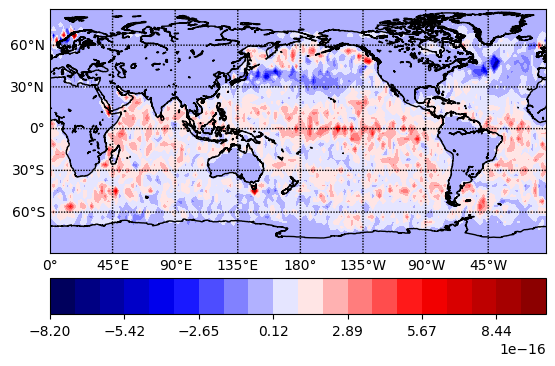

<Figure size 640x480 with 0 Axes>

In [15]:

plot_map(lon_sst,lat_sst,train_data.mean(axis=0),'train_data.png')